# VEP embeddings

Embed haplotypes and patients using genome-wide VEPs scores.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp
import src.tskit as tk
import src.onekg as og
import src.variant_attribution as vb

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
vep_files = va.list_vep_files(as_df=True)

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 859744 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 111422
protein: 2251


In [6]:
vep_files.groupby(["model_location"])["protein"].nunique().sort_values(ascending=False).reset_index(name="n_proteins")

,model_location,n_proteins
0,esm1_t34_670M_UR50D,2251
1,esm2_t33_650M_UR50D,2198
2,esm2_t12_35M_UR50D,2141
3,esm1v_t33_650M_UR90S_1,1795
4,esm1b_t33_650M_UR50S,1791
5,esm2_t48_15B_UR50D,300
6,esm1_t6_43M_UR50S,9


Get the proteins with the most haplotypes.

In [7]:
most_haplotypes = vep_files.groupby(["model_location","protein"])["haplotype"].nunique().sort_values(ascending=False).reset_index(name="n_haplotypes")
most_haplotypes.head(10)

,model_location,protein,n_haplotypes
0,esm1_t34_670M_UR50D,NP_982272.2,476
1,esm1_t34_670M_UR50D,NP_116277.2,467
2,esm2_t33_650M_UR50D,NP_116277.2,467
3,esm2_t12_35M_UR50D,NP_982272.2,396
4,esm2_t33_650M_UR50D,NP_653213.6,389
5,esm2_t12_35M_UR50D,NP_116277.2,389
6,esm1_t34_670M_UR50D,NP_653213.6,389
7,esm2_t33_650M_UR50D,NP_000341.2,364
8,esm1_t34_670M_UR50D,NP_000341.2,364
9,esm1_t34_670M_UR50D,NP_000121.2,363


Get proteins selected from our literature reviews.

In [8]:
candidates = utils.get_candidate_proteins().rename(columns={"RefSeq Protein":"protein"})
candidates.merge(most_haplotypes.loc[most_haplotypes["model_location"]=="esm2_t33_650M_UR50D"], on="protein", how="left")

,Gene,Protein Common Name,protein,RefSeq Transcript,ENSP,RefSeq Protein Stable,model_location,n_haplotypes
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,NaN,NaN
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,ENSP00000417404,NP_000401,esm2_t33_650M_UR50D,20.0
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,ENSP00000003084,NP_000483,esm2_t33_650M_UR50D,174.0
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,ENSP00000350283,NP_009225,esm2_t33_650M_UR50D,144.0
4,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,ENSP00000369497,NP_000050,NaN,NaN
5,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,ENSP00000356771,NP_000121,esm2_t33_650M_UR50D,363.0
6,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,ENSP00000333994,NP_000509,esm2_t33_650M_UR50D,20.0
7,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,ENSP00000376802,NP_000286,esm2_t33_650M_UR50D,27.0
8,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,ENSP00000454071,NP_000518,esm2_t33_650M_UR50D,68.0
9,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,ENSP00000155840,NP_000209,esm2_t33_650M_UR50D,58.0


In [92]:
# protein_ids = candidates.loc[candidates['Gene'].isin(["BRCA1"])]['protein']
# protein_ids = candidates['protein']
# protein_ids = [most_haplotypes['protein'].unique()[3]]
protein_ids = ["NP_001356.1"]
print(protein_ids)

vep_df = va.merge_vep(add_metadata=True, 
                          scoring_strategy=["masked-marginals"],
                          vep_files=vep_files.loc[(vep_files['model_location']=="esm2_t33_650M_UR50D") & 
                                                  (vep_files['protein'].isin(protein_ids)) ]
                          )
print("haplotypes:",vep_df["haplotype"].nunique())
vep_df['site'] = vep_df['protein'] + ":" + vep_df['mutant'] 

# DOES NOT WORK CURRENTLY
# vep_df["haplotype"] = vep_df["haplotype"].apply(utils.decode_haplotype_name)

# Filter out haplotypes with large deletions
# n_before = vep_df["haplotype"].nunique()
# vep_df = vep_df[~vep_df["haplotype"].str.contains("[del{]")]
# n_removed = n_before - vep_df["haplotype"].nunique()
# print(f"Removed {n_removed} haplotype(s) with large deletions")


vep_df = utils.add_hgvsp_id(vep_df, 
                variant_col="site",
                protein_col="protein") 
 

['NP_001356.1']
No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 16 masked-marginals parquet files


Reading files:   0%|          | 0/16 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 7.99GB/s]


VEP dataframe shape: (96, 72)
haplotypes: 16


### Add haplotype frequencies and superpopulations info

In [93]:
# haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
#                                      tx_ids=vep_df['ENST'].unique(), 
#                                     cache_only = True) 
# haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
#                                     tx_ids=vep_df['ENST'].unique(), 
#                                     cache_only = True) 
# haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
#                                          tx_id_method = "intersection",
#                                          use_deepcopy = True)
# # del haplotypes_1kg, haplotypes_hgdp


# vep_df = hs.add_haplotype_freqs(vep_df,
#                         haplotypes=haplotypes)
# vep_df['specific_superpopulation'].value_counts()

## Visualize haplotype embeddings

In [94]:
X = vep_df.pivot_table(index="haplotype", columns="site", values="VEP")
# X = utils.fill_na(X, fillna_method="colmean")

method = "vae"

if method == "umap":
    import umap
    dr_out = umap.UMAP(n_components=2, 
                    random_state=42, 
                    verbose=True).fit_transform(X) 
elif method == "pca":
    from sklearn.decomposition import PCA
    pca = PCA(n_components=10, random_state=42)
    dr_out = pca.fit_transform(X)

elif method == "tsne":
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, 
                random_state=42, 
                verbose=1)
    dr_out = tsne.fit_transform(X)

elif method == "autoencoder":
    from src.autoencoder import train_autoencoder
    # Adjusted hyperparameters for better loss decrease:
    # - Increased learning rate
    # - Increased batch size
    # - Increased contrastive weight
    # - Lowered noise_std
    # - Increased epochs

    ae_out = train_autoencoder(
        X,
        n_epochs=500,            # more epochs for better convergence
        batch_size=64,            # larger batch size for more stable updates
        lr=5e-4,                  # higher learning rate for faster learning
        weight_decay=5e-6,        # slightly less regularization
        use_contrastive=True,
        normalize=True,
        pairwise_loss_weight=1.0,
        reconstruction_loss_weight=1.0,
        contrastive_loss_weight=1.0,   # stronger contrastive signal
        metric="euclidean",
        temperature=0.2,          # slightly lower temperature for sharper contrastive loss
        noise_std=0.05,            # less noise for more stable training
        device="cuda:1"
    ) 
    dr_out = ae_out["embeddings"]
    
elif method == "unet":
    from src.autoencoder import train_unet_1d
    unet_out = train_unet_1d(
        X,
        n_epochs=500,
        batch_size=64,  
        bottleneck_channels=2, 
        in_channels=1,
        base_channels=32,
        latent_dim=128,
        device="cuda"
    )
    dr_out = unet_out["embeddings"]
    
elif method == "vae":
    from src.autoencoder import train_vae
    vae_out = train_vae(
        X,
        n_epochs=500,
        batch_size=64,
        embedding_dim=2,
        hidden_dims=[128, 64, 32],
        lr=1e-3,
        weight_decay=1e-5,
        beta=1.0,
        seed=42,
        normalize=True,
        device="cuda:3"
    )
    dr_out = vae_out["embeddings"]
else:
    raise ValueError(f"Invalid method: {method}")



VAE Epochs: 100%|██████████| 500/500 [00:02<00:00, 175.34it/s]


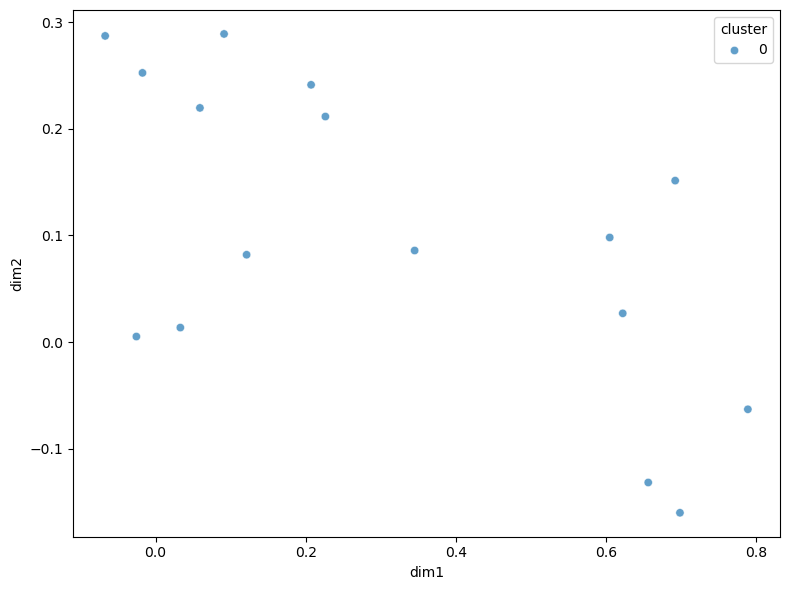

In [95]:
dr_df = pd.concat([
    pd.DataFrame(dr_out, columns=[f"dim{i+1}" for i in range(dr_out.shape[1])]),
    X.index.to_series().reset_index(drop=True)
], axis=1)
# Add VEP values to dr_df
dr_df = dr_df.merge(X, on="haplotype", how="left")
dr_df.index = dr_df["haplotype"].tolist()

# Add mean VEP value to dr_df
dr_df["VEP_mean"] = dr_df[X.columns].mean(axis=1, skipna=True)

from sklearn.cluster import DBSCAN
# Use DBSCAN to assign clusters based on the 2D embedding
dbscan = DBSCAN(eps=0.5, min_samples=5)
dr_df["cluster"] = dbscan.fit_predict(dr_df[["dim1", "dim2"]]).astype(str)
# # Use DBSCAN to assign clusters based on the original X matrix (not the 2D embedding)
# dbscan = DBSCAN(eps=0.25, min_samples=5)
# dr_df["cluster"] = dbscan.fit_predict(X).astype(str)

# Do a quick plot of the 2D embedding
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    x="dim1", y="dim2", data=dr_df,
    hue="cluster", 
    alpha=0.7,  
)  
plt.tight_layout()
plt.show() 

## Train XGBoost model to predict WT variant cluster markers

In [68]:
# feature_importance_df, model = vb.wtvariants_to_clusters_xgboost(dr_df, random_state=42, device="cuda")

## Train model to learn WT x Clinical variant interactions

This cell prepares the data and trains a model (linear model like ridge regression or a neural network) to predict VEP values for each site based on the presence or absence of specific variants in each haplotype.

The workflow includes:
- Melting and transforming the input data to create a binary matrix indicating which variants are present in each haplotype.
- Aligning this matrix with the VEP values for each haplotype.
- Removing any haplotypes with missing data.
- Defining and preparing to train a feedforward neural network that learns to predict the VEP values for all sites from the variant presence/absence patterns.


In [ ]:
#### Neural network ####
# interaction_df, model = vb.wtvariants_to_vep_neural_network(vep_df)

#### Linear model ####
interaction_df, model = vb.wtvariants_to_vep_linear_model(vep_df, model_type="ridge")

print("Top (wt_variant, site) interactions by estimated linear model importance (including haplotype counts):")
print(interaction_df.head(10))

vep_matrix shape:  (16, 6)
wt_matrix shape:  (16, 16)
Top (wt_variant, site) interactions by estimated linear model importance (including haplotype counts):
   wt_variant               site  interaction_strength  n_haplotypes  \
74     585P>T  NP_001356.1:R629Q              0.166514             1   
76     585P>T  NP_001356.1:T654I              0.086494             1   
68     567E>Q  NP_001356.1:R629Q              0.047127             1   
38     305T>N  NP_001356.1:R629Q              0.046901             1   
80     708I>T  NP_001356.1:R629Q              0.034302             1   
56     400D>H  NP_001356.1:R629Q              0.033178             1   
70     567E>Q  NP_001356.1:T654I              0.031957             1   
2      100T>I  NP_001356.1:R629Q              0.030377             1   
83     708I>T  NP_001356.1:V761I              0.029544             1   
39     305T>N  NP_001356.1:T100I              0.026707             1   

    interaction_strength_weighted  
74            

<Axes: >

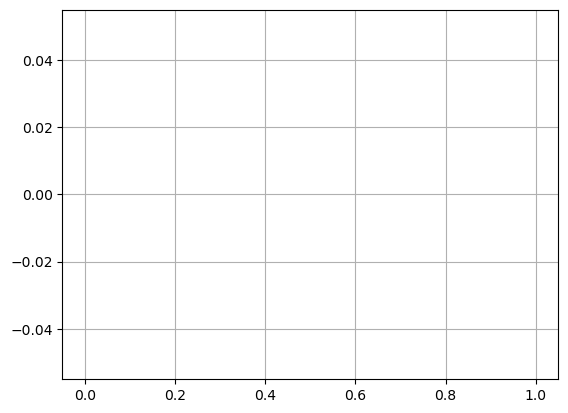

In [130]:
interaction_df.loc[interaction_df["interaction_strength"]>0]["interaction_strength"].hist()

### Extract WT variant x clinical variant interactions from original autoencoder

Infer WT x clinical variant interactions by iteratively feeding in subsets of haplotypes that contain a given WT variants and measuring the effect on the predicted site-specific VEPs.

In [ ]:
# autoencoder = ae_out["model"]

# # Get device from model parameters
# device = next(autoencoder.parameters()).device

# # DataFrame to store results
# wt_site_importance = []

# # Compute baseline reconstruction (no masking)
# X_tensor_full = torch.tensor(X.values, dtype=torch.float32, device=device)
# with torch.no_grad():
#     # The autoencoder returns a tuple (recon, embedding), so we need to unpack it
#     recon_full = autoencoder(X_tensor_full)[0].cpu().numpy()

# for wt in X_epistasis_clean.columns:
#     haplotypes_with_wt_variant = X_epistasis_clean.index[X_epistasis_clean[wt] == 1]

#     X_masked = X.copy()
#     X_masked.loc[haplotypes_with_wt_variant.tolist(), :] = 0  # mask out this wt_variant for all haplotypes

#     # Prepare input for autoencoder
#     X_tensor = torch.tensor(X_masked.values, dtype=torch.float32, device=device)

#     # Compute reconstruction with this wt masked
#     with torch.no_grad():
#         recon_masked = autoencoder(X_tensor)[0].cpu().numpy()

#     # For each site (column), compute the mean absolute difference in reconstruction
#     for i, site in enumerate(X.columns):
#         # Only consider haplotypes where this wt_variant was present (i.e., those that were masked)
#         idx = [X.index.get_loc(h) for h in haplotypes_with_wt_variant]
#         if len(idx) == 0:
#             continue
#         diff = abs(recon_full[idx, i] - recon_masked[idx, i]).mean()
#         wt_site_importance.append({
#             "wt_variant": wt,
#             "site": site,
#             # Mean absolute difference in reconstruction
#             "interaction_strength": diff
#         })

# # Convert to DataFrame
# interaction_df = pd.DataFrame(wt_site_importance).sort_values("interaction_strength", ascending=False)

# # Show top results
# print(interaction_df.head(10))

### Get the top most important WT variants overall

In [98]:
interaction_df.groupby("wt_variant")["interaction_strength"].sum().sort_values( ascending=False)

wt_variant
585P>T    0.271925
305T>N    0.123408
567E>Q    0.109821
708I>T    0.081742
400D>H    0.076682
35F>Y     0.060157
168V>M    0.060030
100T>I    0.057669
251I>V    0.057377
32S>G     0.056341
11A>V     0.055189
303I>V    0.053015
187V>I    0.048461
533S>G    0.048039
REF       0.033548
761V>I    0.020887
Name: interaction_strength, dtype: float64

### Get the top most important sites overall

In [99]:
site_scores = interaction_df.groupby("site")["interaction_strength"].sum().sort_values( ascending=False)
# Add site_interaction_mean to vep_df
vep_df["site_interaction_sum"] = vep_df["site"].map(site_scores.to_dict())
site_scores


site
NP_001356.1:R629Q    0.522661
NP_001356.1:T654I    0.242661
NP_001356.1:T100I    0.173029
NP_001356.1:D229V    0.115899
NP_001356.1:V761I    0.111598
NP_001356.1:G220V    0.048442
Name: interaction_strength, dtype: float64

## Plot site importance by clinical signficance

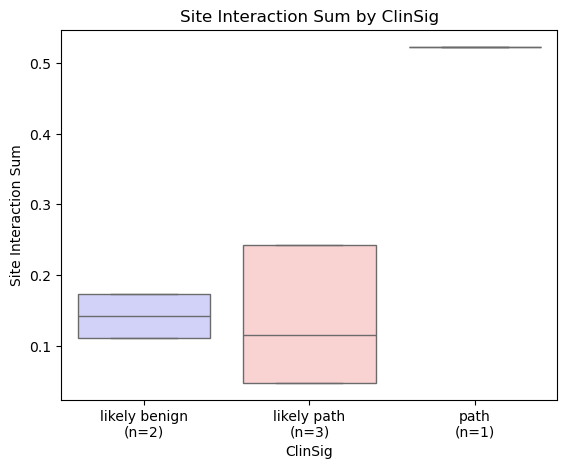

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt


clinsig_palette = utils.get_clinsig_palette()
 
vep_df = vep_df.sort_values("clinsig")
# Compute counts for each clinsig group
clinsig_counts = vep_df.groupby("clinsig",observed=True)["site"].nunique().reindex(list(clinsig_palette.keys()))
# Create new x-axis labels with counts
# Get the actual x-axis order from the plot (unique values in vep_df["clinsig"] in order of appearance)
xaxis_order = list(vep_df["clinsig"].unique())
x_labels = [
    f"{clinsig.replace('_', ' ')}\n(n={clinsig_counts[clinsig].astype(int) if not pd.isna(clinsig_counts[clinsig]) else 0})"
    for clinsig in xaxis_order
]

# Plot with new labels
ax = sns.boxplot(
    data=vep_df,
    x="clinsig",
    y="site_interaction_sum", 
    hue="clinsig",
    palette=clinsig_palette,
    legend=False
)
# Set the correct number of ticks before setting tick labels
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels)
ax.set_xlabel("ClinSig")
ax.set_ylabel("Site Interaction Sum")
ax.set_title("Site Interaction Sum by ClinSig")
plt.show()


In [101]:
import numpy as np

# Identify the REF haplotype row(s)
dr_df["is_ref"] = dr_df["haplotype"].str.endswith(":REF")
ref_mask = dr_df["is_ref"]

#### EDIT DISTANCE ####
dr_df = utils.add_edits(dr_df)
dr_df["edits_clipped"] = dr_df["edits"].clip(upper=10)

#### HIGH-DIMENSIONAL VEP DISTANCE ####
# Compute distance to the REF based on all the VEP columns (col names in X)
vep_cols = list(X.columns)
# Get the REF row(s) in dr_df
ref_vep = dr_df.loc[ref_mask, vep_cols].iloc[0].values
# Compute Euclidean distance in VEP space for each row to REF
dr_df["ref_hd_dist"] = np.linalg.norm(dr_df[vep_cols].values - ref_vep, axis=1)

#### LOW-DIMENSIONAL VEP DISTANCE ####
# Get the dim* columns (e.g., dim1, dim2, ...)
dim_cols = [col for col in dr_df.columns if col.startswith("dim")]
# Get the REF coordinates (assume only one REF row, else take the first)
ref_coords = dr_df.loc[ref_mask, dim_cols].iloc[0].values
# Compute Euclidean distance for each row to REF
dr_df["ref_ld_dist"] = np.linalg.norm(dr_df[dim_cols].values - ref_coords, axis=1)

Text(0.05, 0.95, '$R^2$ = 0.173\np = 1.23e-01')

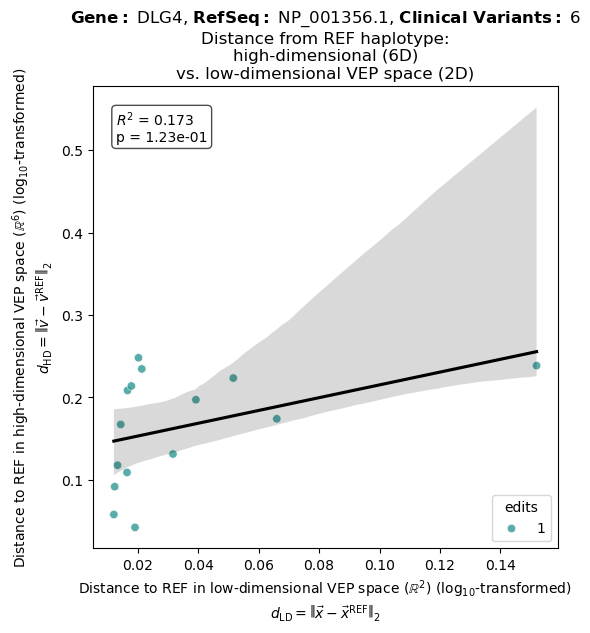

In [102]:
import seaborn as sns
from scipy.stats import linregress

x_col = "ref_hd_dist"
y_col = "ref_ld_dist"
hue_col = "edits"
log_x = True
log_y = True
plot_df = dr_df.dropna(subset=[x_col, y_col]).sort_values(by="edits", ascending=True)
plot_df = plot_df.loc[plot_df["is_ref"]==False]

if log_x:
    plot_df[x_col] = np.log10(plot_df[x_col] + 1)
if log_y:
    plot_df[y_col] = np.log10(plot_df[y_col] + 1)

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
# Use scatterplot to color by 'edits', then overlay regression line
ax = sns.scatterplot(x=x_col, y=y_col, data=plot_df, hue=hue_col, palette="viridis", alpha=0.75)
sns.regplot(x=x_col, y=y_col, data=plot_df, scatter=False, ax=ax, color="black")
# Hide legend if x_col or y_col is the same as hue_col
if x_col == hue_col or y_col == hue_col:
    ax.get_legend().remove()
ax.set_xlabel(
    r"Distance to REF in low-dimensional VEP space ($\mathbb{R}^2$)"
    + (" (log$_{10}$-transformed)" if log_x else "")
    + "\n"
    + r"$d_\mathrm{LD} = \left\| \vec{x} - \vec{x}^\mathrm{REF} \right\|_2$"
)
ax.set_ylabel(
    r"Distance to REF in high-dimensional VEP space ($\mathbb{R}^{%d}$)" % X.shape[1]
    + (" (log$_{10}$-transformed)" if log_y else "")
    + "\n"
    + r"$d_\mathrm{HD} = \left\| \vec{v} - \vec{v}^\mathrm{REF} \right\|_2$"
)
protein_id = vep_df["protein"].iloc[0]
gene_id = vep_df["GENEINFO"].iloc[0].split(":")[0]
ax.set_title(
    f"$\\bf{{Gene:}}$ {gene_id}, $\\bf{{RefSeq:}}$ {protein_id}, $\\bf{{Clinical\\ Variants:}}$ {X.shape[1]}"
    "\nDistance from REF haplotype:"
    f"\nhigh-dimensional ({X.shape[1]}D)\nvs. low-dimensional VEP space ({2}D)"
)


# Calculate R2 and p-value
slope, intercept, r_value, p_value, std_err = linregress(plot_df[x_col], plot_df[y_col])
r2 = r_value ** 2

# Annotate plot with R2 and p-value
ax.text(
    0.05, 0.95,
    f"$R^2$ = {r2:.3f}\np = {p_value:.2e}",
    transform=ax.transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)

In [103]:
wt_variants = vb.get_wt_variant_matrix(vep_df, as_df=True)
wt_variants

,haplotype,wt_variant,dummy
0,ENSP00000497806:REF,REF,1
30,ENSP00000497806:533S>G,533S>G,1
36,ENSP00000497806:400D>H,400D>H,1
42,ENSP00000497806:567E>Q,567E>Q,1
48,ENSP00000497806:35F>Y,35F>Y,1
54,ENSP00000497806:585P>T,585P>T,1
29,ENSP00000497806:305T>N,305T>N,1
60,ENSP00000497806:303I>V,303I>V,1
66,ENSP00000497806:168V>M,168V>M,1
72,ENSP00000497806:708I>T,708I>T,1


In [104]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=vep_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=vep_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)
# del haplotypes_1kg, haplotypes_hgdp

dr_df["ENSP"] = dr_df["haplotype"].str.split(":").str[0]
dr_df = hs.add_haplotype_freqs(dr_df,
                               haplotypes=haplotypes)

dr_df["specific_pop"] = dr_df["specific_population"].str.split(":").str[-1].fillna("N/A")
dr_df["specific_superpop"] = dr_df["specific_superpopulation"].str.split(":").str[-1].fillna("N/A")
# Add a col indicating whether the same is Puerto Rican
dr_df["top_pop_is_PUR"] = (dr_df["top_population"].str.endswith(":PUR")).astype(str)
dr_df["specific_pop_is_PUR"] = (dr_df["specific_pop"]=="PUR").astype(str)
dr_df["top_population_freq"].fillna(0, inplace=True)
dr_df["freq_1000GENOMES:phase_3:PUR"].fillna(0, inplace=True)


dr_df["specific_superpop"].value_counts()

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


...

Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 7.59GB/s]


Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using all 3 cohorts.
Using 38 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_population
1000GENOMES:phase_3:CHB    2
1000GENOMES:phase_3:GIH    1
1000GENOMES:phase_3:STU    1
1000GENOMES:phase_3:FIN    1
1000GENOMES:phase_3:YRI    1
1000GENOMES:phase_3:MXL    1
1000GENOMES:phase_3:GWD    1
1000GENOMES:phase_3:PJL    1
1000GENOMES:phase_3:GBR    1
Name: count, dtype: int64

Percentage of population-specific haplotypes: 62.50%

Number of variants specific to each superpopulation:
specific_superpopulation
1000GENOMES:phase_3:SAS    4
1000GENOMES:phase_3:AFR    3
1000GENOMES:phase_3:EAS    2
1000GENOMES:phase_3:EUR    2
1000GENOMES:phase_3:AMR    1
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 75.00%


/tmp/ipykernel_1254908/1773088378.py:21: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_1254908/1773088378.py:22: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=T

specific_superpop
N/A    4
SAS    4
AFR    3
EUR    2
EAS    2
AMR    1
Name: count, dtype: int64

In [121]:
interaction_idx = 0

# Select top site
site = site_scores.index[interaction_idx]
# site = "NP_116277.2:G697R"

# Select top wt_variant interacting with that site
wt_var = interaction_df.loc[interaction_df["site"]==site, "wt_variant"].iloc[0]

# Add a column indicating whether each haplotype contains this variant
wt_variants = vb.get_wt_variant_matrix(vep_df, as_df=True)
wt_haplotypes = wt_variants.loc[wt_variants["wt_variant"]==wt_var]["haplotype"].unique().tolist()
dr_df[f"{wt_var}"] = dr_df["haplotype"].isin(wt_haplotypes)
print("Clinical variant:",site)
print(f"WT variant: {wt_var} ({len(wt_haplotypes)} haplotypes have this WT variant)")

# wt_var = interaction_df["wt_variant"].tolist()[interaction_idx]
# site = interaction_df["site"].tolist()[interaction_idx]

va.plot_dr_with_kde_topo(
        dr_df.loc[~dr_df["haplotype"].str.contains("[del{]")], 
        x_col="dim1",
        y_col="dim2",
        hover_data=["cluster","haplotype","VEP_mean","edits","population"],
        add_kde=True, 
        point_size = 5,
        add_shadow = False,
        # symbol_col = wt_var,
        symbol_col = "specific_pop_is_PUR",
        hue_col = site,
        # hue_col = "VEP_mean",
        # hue_col = "top_population",
        # hue_col = "freq_1000GENOMES:phase_3:PUR",
        # hue_col = "cluster"
        scatter_kwargs = {"size": "edits_clipped", #"freq_1000GENOMES:phase_3:PUR", 
                          "size_max": 10}, 
        point_outline_kwargs = {"width": .5, "color": "white"},
        )

Clinical variant: NP_001356.1:R629Q
WT variant: 585P>T (1 haplotypes have this WT variant)


Which populations are most sensitive to the clinical variant?

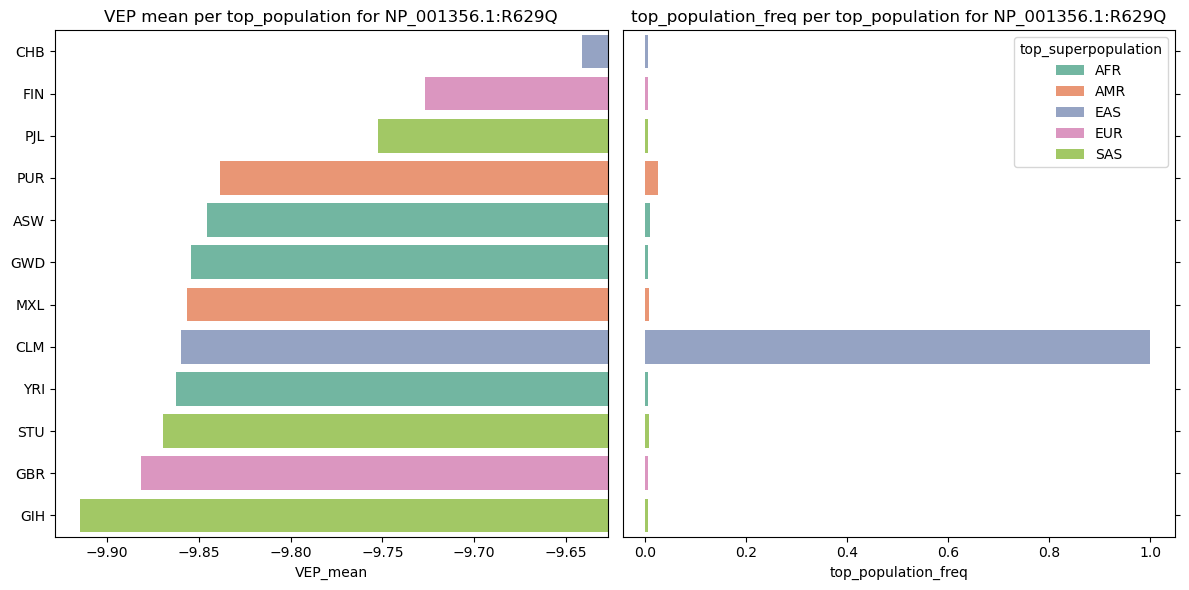

In [106]:

x_var = "top_population_freq"
y_var = "top_population"
pop_superpop_map = dict(zip( dr_df["top_population"] , dr_df["top_superpopulation"]))

vep_per_pop = dr_df.groupby(y_var).agg({site: "mean","top_population_freq":"mean"}).reset_index().rename(columns={site: "VEP_mean"})
vep_per_pop["top_superpopulation"] = vep_per_pop[y_var].map(pop_superpop_map).str.split(":").str[-1]
vep_per_pop[y_var] = vep_per_pop[y_var].str.split(":").str[-1]
vep_per_pop["VEP_mean_weighted"] = vep_per_pop["VEP_mean"] * vep_per_pop["top_population_freq"]
vep_per_pop = vep_per_pop.loc[vep_per_pop[y_var]!="all"]
vep_per_pop.sort_values(x_var, ascending=False, inplace=True)
vep_per_pop.sort_values("VEP_mean", ascending=False, inplace=True)

import matplotlib.pyplot as plt

palette = utils.get_superpop_palette()

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 6), sharey=True, gridspec_kw={"width_ratios": [1, 1]}
)

# Left barplot: VEP_mean (mirrored, left-to-right, i.e., x-axis flipped)
sns.barplot(
    data=vep_per_pop,
    x="VEP_mean",
    y=y_var,
    hue="top_superpopulation",
    palette=palette,
    orient="h",
    ax=ax1,
    dodge=False,
)
# Flip the x-axis direction (left-to-right)
xmin = vep_per_pop["VEP_mean"].min()
xmax = vep_per_pop["VEP_mean"].max()
xrange = xmax - xmin
ax1.set_xlim(xmin - 0.05 * xrange, xmax + 0.05 * xrange)
ax1.set_ylabel("")  # Remove y-label to avoid duplication
ax1.set_xlabel("VEP_mean")
ax1.set_title(f"VEP mean per {y_var} for {site}")
ax1.yaxis.tick_left()
ax1.yaxis.set_label_position("left")
# Remove legend from left plot
ax1.legend_.remove() if ax1.get_legend() else None

# Right barplot: top_population_freq (left to right)
sns.barplot(
    data=vep_per_pop,
    x=x_var,
    y=y_var,
    hue="top_superpopulation",
    palette=palette,
    orient="h",
    ax=ax2,
    dodge=False,
)
xmin2 = vep_per_pop[x_var].min()
xmax2 = vep_per_pop[x_var].max()
xrange2 = xmax2 - xmin2
ax2.set_xlim(xmin2 - 0.05 * xrange2, xmax2 + 0.05 * xrange2)
ax2.set_ylabel("")
ax2.set_xlabel(x_var)
ax2.set_title(f"{x_var} per {y_var} for {site}")
# Move ytick labels to the right side
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

# Sort the legend by the order of the palette keys
handles, labels = ax2.get_legend_handles_labels()
ordered_labels = [k for k in palette.keys() if k in labels]
ordered_handles = [handles[labels.index(l)] for l in ordered_labels]
ax2.legend(ordered_handles, ordered_labels, title="top_superpopulation", loc="best")

plt.tight_layout()

In [141]:
site_positions = utils.variants_to_positions(X.columns.tolist()).sort_values("variant_position")
site_positions.tail(10) 


,variant,variant_position,REF,ALT
61,NP_000341.2:D2177N,2177,N,N
93,NP_000341.2:F2188S,2188,S,S
19,NP_000341.2:A2216V,2216,V,V
219,NP_000341.2:L2229P,2229,P,P
84,NP_000341.2:E2233V,2233,V,V
299,NP_000341.2:Q2238R,2238,R,R
220,NP_000341.2:L2241P,2241,P,P
422,NP_000341.2:V2244E,2244,E,E
387,NP_000341.2:S2255I,2255,I,I
358,NP_000341.2:R2263Q,2263,Q,Q


Normalizing columns


/tmp/ipykernel_3829329/1972633873.py:17: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



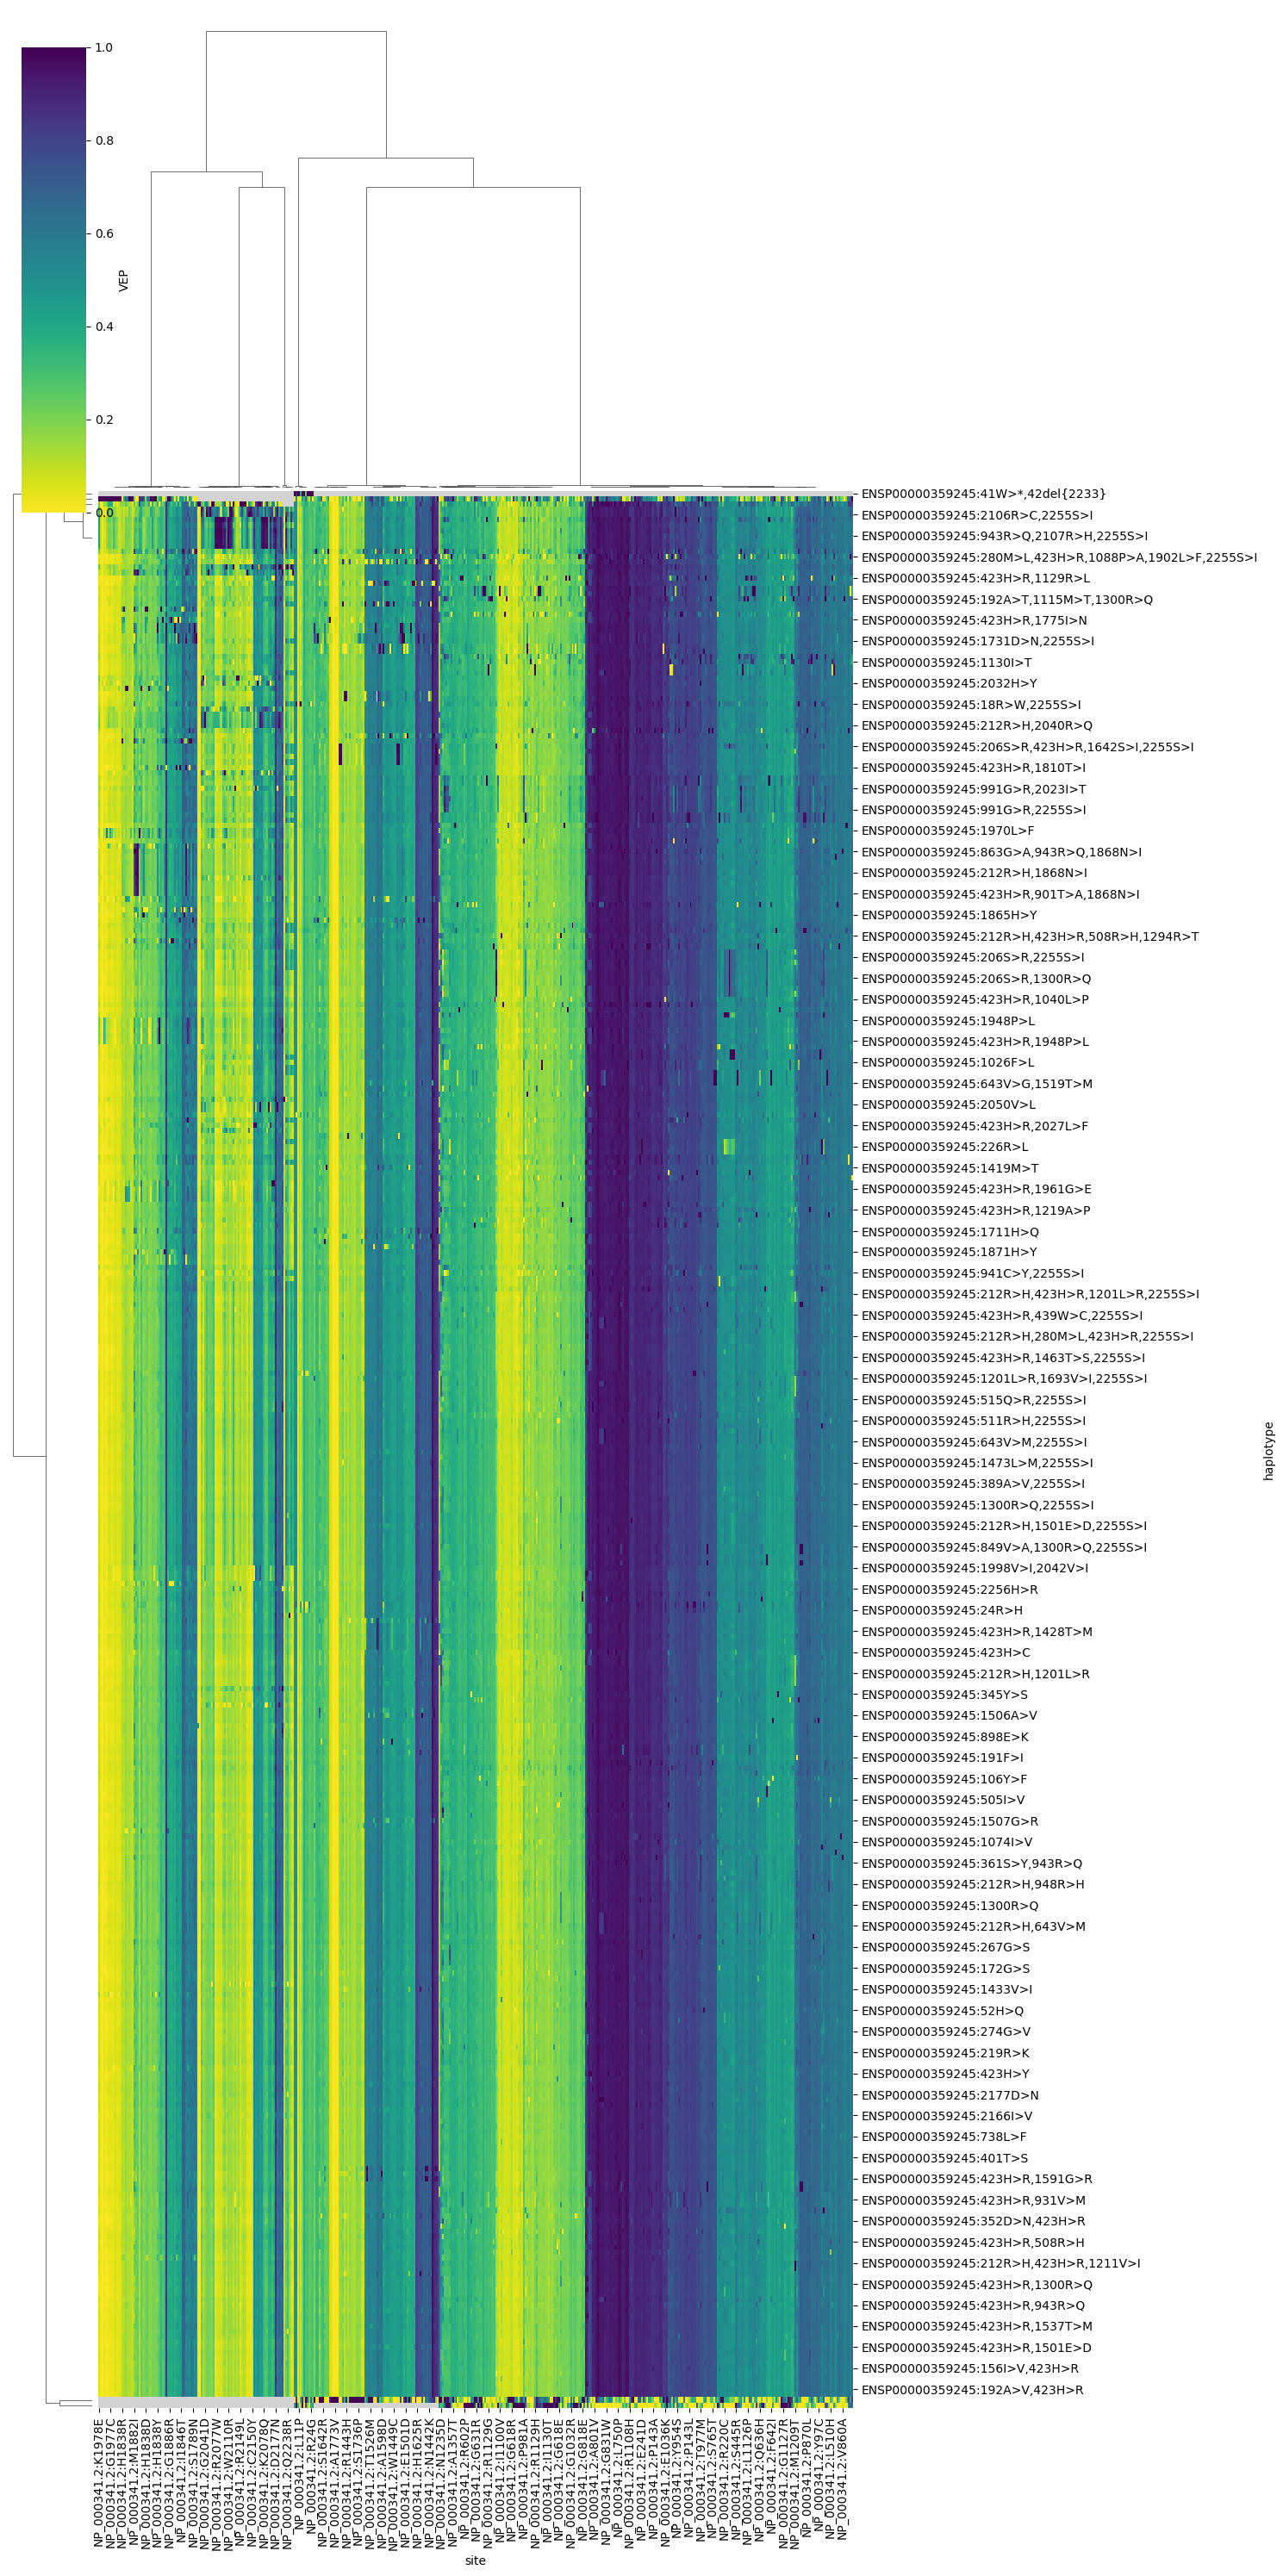

In [143]:
# Note: sns.clustermap does not support a 'mask' argument as of seaborn 0.12+.
# Instead, mask the data by filling NaNs with a distinct value (e.g., -999) and optionally
# use a custom colormap to visually distinguish missing values.

X_norm = utils.minmax_normalize(X, procedure=["cols"])
X_norm = X_norm[site_positions["variant"].tolist()]

# Optionally, set a colormap with a color for bad values
import matplotlib as mpl
import seaborn as sns

# Create a copy to avoid modifying original
X_plot = X_norm.copy()
X_plot = X_plot.fillna(-999)

# Create a colormap that shows missing values as gray
cmap = mpl.cm.get_cmap("viridis_r").copy()
cmap.set_bad(color="lightgray")
cmap.set_under(color="lightgray")

# Mask values for colorbar (so -999 is not in the colorbar range)
vmin = X_norm.min().min()
sns.clustermap(
    X_plot,
    col_cluster=True,
    row_cluster=True,
    figsize=(15, 30),
    cmap=cmap,
    cbar_kws={"label": "VEP"},
    dendrogram_ratio=(.1, .2),
    vmin=vmin,  # so -999 is below colorbar range
)

Shown the difference in VEP between haplotypes with and without the WT variant.

This tells you which WT variants are interacting with clinical variants.

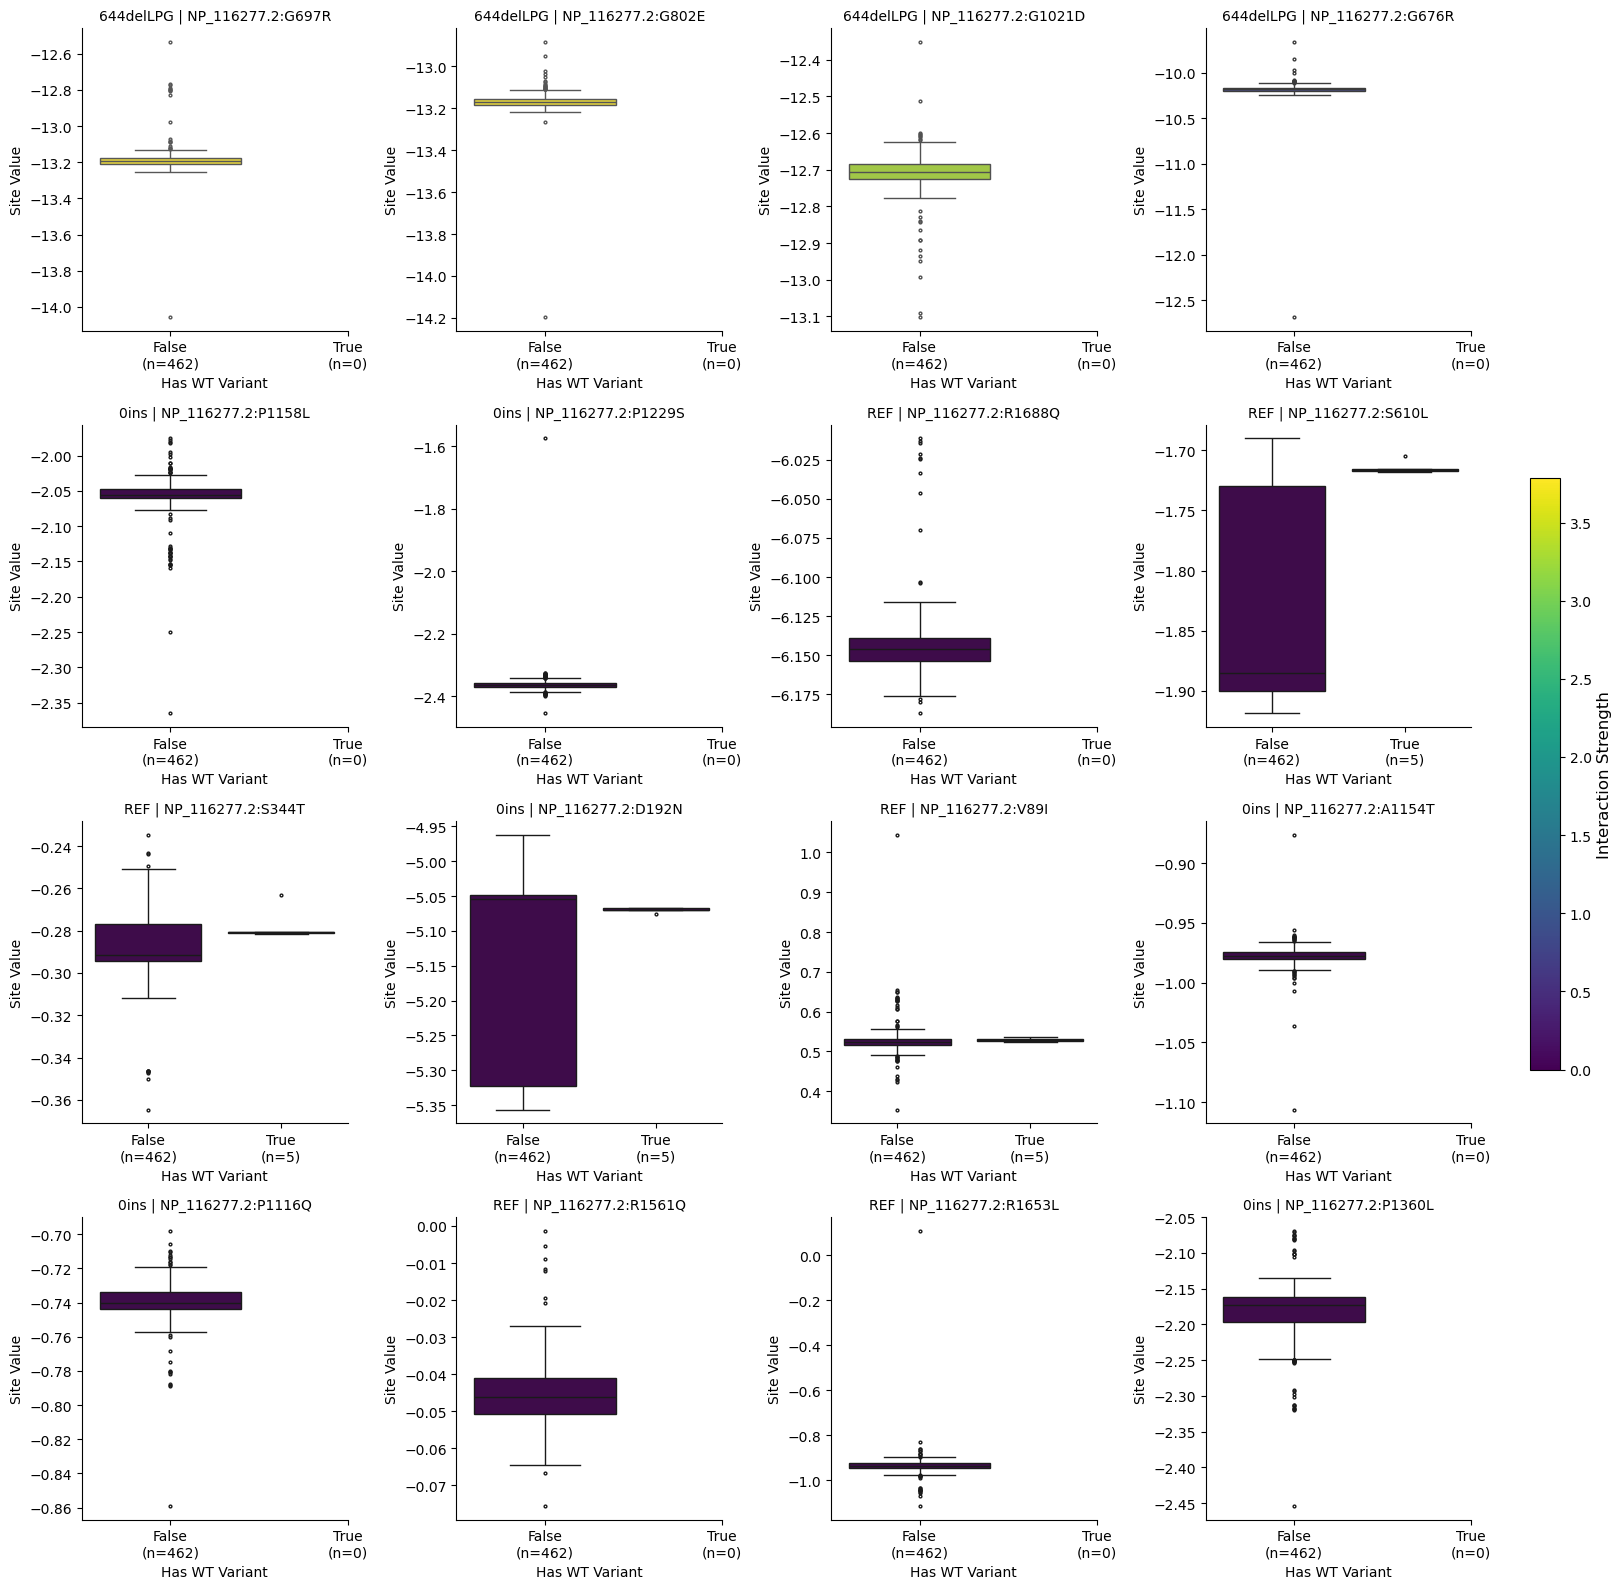

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === PARAM: Set the colormap for interaction strength here ===
INTERACTION_STRENGTH_PALETTE = "viridis"  # e.g., "plasma", "viridis", "magma", etc. (sequential, not diverging)

# === PARAM: Number of top pairs to plot ===
N_PAIRS = 16  # e.g., 4x4 grid

# --- 1. Get the top N_PAIRS wt_variant x clinical_variant pairs by interaction_strength (preaggregation) ---

# Sort interaction_df by interaction_strength descending, take top N_PAIRS
top_pairs_df = interaction_df.sort_values("interaction_strength", ascending=False).head(N_PAIRS)

# If there are fewer than N_PAIRS, adjust
actual_n_pairs = top_pairs_df.shape[0]

# --- 2. Prepare data for plotting ---

plot_df = dr_df.copy()

# For each unique wt_variant and site in the top pairs, ensure the columns exist in plot_df
for wt_var in top_pairs_df["wt_variant"].unique():
    if wt_var not in plot_df.columns: 
        plot_df[wt_var] = plot_df["haplotype"].isin(wt_haplotypes)
for site in top_pairs_df["site"].unique():
    if site not in plot_df.columns:
        # If site column doesn't exist, skip (should exist if dr_df was constructed as before)
        continue

# Build a lookup for interaction strength for (wt_variant, site)
interaction_strength_lookup = (
    interaction_df.set_index(["wt_variant", "site"])["interaction_strength"].to_dict()
)

# --- 3. Melt the dataframe to long format for seaborn, for only the top pairs ---

melted = []
for idx, row in top_pairs_df.iterrows():
    wt_var = row["wt_variant"]
    site = row["site"]
    if wt_var in plot_df.columns and site in plot_df.columns:
        tmp = plot_df[["haplotype", wt_var, site]].copy()
        tmp = tmp.rename(columns={wt_var: "wt_var", site: "site_value"})
        tmp["wt_variant"] = wt_var
        tmp["site"] = site
        # Add interaction strength for coloring
        tmp["interaction_strength"] = interaction_strength_lookup.get((wt_var, site), np.nan)
        melted.append(tmp)
if not melted:
    raise ValueError("No valid (wt_var, site) pairs found in data for plotting.")
facet_df = pd.concat(melted, ignore_index=True)

# Remove extreme outliers for each (wt_variant, site) pair using IsolationForest
from sklearn.ensemble import IsolationForest

def remove_outliers(group):
    # Only attempt outlier removal if there are enough samples
    if group.shape[0] < 10:
        return group
    X = group[["site_value"]].values
    iso = IsolationForest(contamination=0.01, random_state=42)
    preds = iso.fit_predict(X)
    filtered = group[preds == 1]
    n_dropped = group.shape[0] - filtered.shape[0]
    if n_dropped > 0:
        print(f"Dropped {n_dropped} haplotypes as outliers for {group.name}.")
    return filtered

# facet_df = facet_df.groupby(["site"], group_keys=False).apply(remove_outliers)
facet_df = facet_df[facet_df["site_value"] != 0]

# Get global vmin/vmax for consistent color scale
all_strengths = [
    interaction_strength_lookup.get((row["wt_variant"], row["site"]), np.nan)
    for _, row in top_pairs_df.iterrows()
]
vmin = np.nanmin(all_strengths)
vmax = np.nanmax(all_strengths)
cmap = plt.get_cmap(INTERACTION_STRENGTH_PALETTE)

# --- 4. Use seaborn FacetGrid for plotting ---

# For a grid, try to make it as square as possible
n_cols = int(np.ceil(np.sqrt(actual_n_pairs)))
n_rows = int(np.ceil(actual_n_pairs / n_cols))

# Add a "pair_label" column for facetting
facet_df["pair_label"] = facet_df["wt_variant"] + " | " + facet_df["site"]

# To preserve order, get the pair_labels in the order of top_pairs_df
pair_labels = [f"{row['wt_variant']} | {row['site']}" for _, row in top_pairs_df.iterrows()]
facet_df["pair_label"] = pd.Categorical(facet_df["pair_label"], categories=pair_labels, ordered=True)

g = sns.FacetGrid(
    facet_df,
    col="pair_label",
    col_wrap=n_cols,
    margin_titles=True,
    sharex=False,
    sharey=False,
    height=4,
    aspect=1
)

def boxplot_with_counts_and_color(data, color=None, **kwargs):
    ax = plt.gca()
    # Get the interaction strength for this facet
    if len(data) == 0:
        return
    interaction_strength = data["interaction_strength"].iloc[0]
    # Map interaction strength to color
    norm_strength = (interaction_strength - vmin) / (vmax - vmin) if vmax > vmin else 0.5
    box_color = cmap(norm_strength)
    # Draw boxplot
    sns.boxplot(data=data, x="wt_var", y="site_value", ax=ax, color=box_color, fliersize=2)
    # Count unique haplotypes in each x category (True/False)
    counts = data.groupby("wt_var")["haplotype"].nunique()
    xlabels = [f"{cat}\n(n={counts.get(cat,0)})" for cat in [False, True]]
    ax.set_xticks([0, 1])
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Has WT Variant")
    ax.set_ylabel("Site Value")
    # Optionally, add the interaction strength as a title or annotation
    ax.set_title(f"Strength: {interaction_strength:.2f}", fontsize=10)

g.map_dataframe(boxplot_with_counts_and_color)
g.set_titles(col_template="{col_name}")
g.tight_layout()

# Add a single colorbar for interaction strength
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# Only show legend once, outside the grid
cbar = g.fig.colorbar(sm, ax=g.axes, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("Interaction Strength", fontsize=12)

plt.show()


## Visualize patient embeddings

WIP: writing a pipeline to construct genome-wide VEP matrices that can scale better.

In [ ]:
from tqdm import tqdm
from IPython.display import clear_output

# Initialize empty list to store matrices
X_list = []
haps_to_samples_list = []
vep_samples_list = []

# Subset to ESM2 model
vep_files_sub = vep_files.loc[(vep_files['scoring_strategy']=="masked-marginals") & (vep_files['model_location']=="esm2_t33_650M_UR50D")]
vep_files_sub['ENSP'] = vep_files_sub['haplotype'].str.split(':').str[0]

# Iterate over ENSPs
for tx_id in tqdm(vep_files_sub['protein'].unique(),
                  desc="Iterating over ENSPs"):
    vep_df = va.merge_vep(add_metadata=True,  
                          scoring_strategy=["masked-marginals"],
                          vep_files=vep_files_sub.loc[vep_files_sub['protein']==tx_id]
                          )
    vep_df['site'] = vep_df['protein'] + ":" + vep_df['mutant'] 
    try:
        haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                        tx_ids=vep_df['ENST'].unique(),
                                        cache_only = True)
    except:
        haplotypes_hgdp = None

    try:
        haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                        tx_ids=vep_df['ENST'].unique(),
                                        cache_only = True)
    except:
        haplotypes_1kg = None
    
    if haplotypes_1kg is None and haplotypes_hgdp is None:
        continue
        
    haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                             verbose=True)
    haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=True, 
                                           duplicate_ref=True,
                                           )
    haps_to_samples_list.append(haps_to_samples.copy())
    vep_samples = va.merge_vep_and_samples(vep_df,
                                       haps_to_samples,
                                       vep_cols = ["VEP"],
                                       tx_id_col = ["ENST","ENST_haplosaurus"],
                                       site_col = "site",
                                       haplotype_col = "haplotype",
                                       protein_col = "protein",  
                                       check_ploid=False,
                                       verbose=True)
    vep_samples_list.append(vep_samples.copy())
    X_chunk = utils.vep_to_matrix(vep_samples,
                        sample_col = "sample",
                        site_col = "site",
                        ploid_col = "ploid",
                        value_col = "VEP",
                        fillna_method="colmean",
                        duplicate_ref_hap=False)

    # X_chunk = utils.vep_to_matrix_torch(vep_samples,        
    #                                     sample_col = "sample",
    #                                     site_col = "site",
    #                                     ploid_col = "ploid",
    #                                     value_col = "VEP",
    #                                     device = "cuda:3",
    #                                     fillna_method=None,
    #                                     return_as = "pandas",
    #                                     verbose = True 
                        
    print(X_chunk.shape)
    X_list.append(X_chunk.copy())
    clear_output(wait=True)
     
X = pd.concat(X_list, axis=1, join="outer") 

X

In [ ]:
# utils.calc_percent_nas(X)
# X = utils.fill_na(X, fillna_method="colmean")

# Calculate the number of missing values before filling
num_missing = X.isna().sum().sum()
total_values = X.shape[0] * X.shape[1]
percent_missing = (num_missing / total_values) * 100

# Fill NAs with column means
X_filled = X.fillna(X.mean())

print(f"Filled {num_missing} missing values ({percent_missing:.2f}% of the DataFrame) with column means.")


Filled 3706320 missing values (78.12% of the DataFrame) with column means.


### Import haplotypes

In [152]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=vep_df['ENST'].unique(),
                                    #  max_tx_ids=100, 
                                    cache_only = True) 

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

In [154]:
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=vep_df['ENST'].unique(),
                                    # tx_ids=haplotypes_hgdp.keys(),
                                    cache_only = True) 


Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Merge haplotypes together into one object.

In [155]:
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)
# del haplotypes_1kg, haplotypes_hgdp

Using deepcopy
Merging 1 tx_ids using intersection


Merging haplotype datasets: 0it [00:00, ?it/s]

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 467 haplotypes across 1 tx_ids.


In [623]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=True, 
                                           duplicate_ref=True,
                                           verbose=True,
                                           )
print(f"{haps_to_samples['sample'].nunique()} samples across {haps_to_samples["haplotype"].nunique()} haplotypes")
haps_to_samples.head() 

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
Samples before merging: 3826
Samples after merging: 3826
Adding REF haplotypes to the DataFrame
Samples after adding REF haplotypes: 3827
Final shape: (7862, 15)
>> haplotype(s): 144
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3827
>> population(s): 155
>> superpopulation(s): 6
>> sex(s): 2
3827 samples across 144 haplotypes


,ENST_haplosaurus,cohort_sample,haplotype,cohort,sample,ploid_count,ploid,sex,Biosample ID,Population code,population_name,superpopulation,superpopulation_name,population,Data collections
0,ENST00000357654,HGDP00649,ENSP00000350283:REF,HGDP,REF,2,0,<NA>,NaN,NaN,REF,REF,REF,REF,Human Genome Diversity Project
0,ENST00000357654,HGDP00649,ENSP00000350283:REF,HGDP,REF,2,1,<NA>,NaN,NaN,REF,REF,REF,REF,Human Genome Diversity Project
0,ENST00000357654,HGDP00649,ENSP00000350283:REF,HGDP,HGDP00649,2,0,female,NaN,NaN,Bedouin,NaN,Middle East (HGDP),BedouinHGDP,Human Genome Diversity Project
1,ENST00000357654,HGDP00649,"ENSP00000350283:693D>N,871P>L,1038E>G,1183K>R,...",HGDP,HGDP00649,2,1,female,NaN,NaN,Bedouin,NaN,Middle East (HGDP),BedouinHGDP,Human Genome Diversity Project
2,ENST00000357654,1000GENOMES:phase_3:NA20874,ENSP00000350283:REF,1000GENOMES,NA20874,2,0,female,SAME123597,GIH,Gujarati,SAS,South Asian Ancestry,GIH,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."


Check for samples that don't have exactly 2 haplotypss per transcript.

In [624]:
bad_ploid = haps_to_samples.loc[haps_to_samples['ploid_count']!=2] 
print(round(bad_ploid.shape[0]/haps_to_samples.shape[0]*100,2),"% of rows have ploidy != 2")
print(bad_ploid['ENST_haplosaurus'].nunique(),"unique ENST_haplosaurus")
bad_ploid['ploid_count'].value_counts()

0.0 % of rows have ploidy != 2
0 unique ENST_haplosaurus


Series([], Name: count, dtype: int64)

Normalize VEP scores within each protein.

In [625]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, Normalizer
# scaler = MinMaxScaler()
# scaler = Normalizer()
scaler = RobustScaler()

# Group by site and slot, then apply minmax scaling
vep_df.loc[:,"VEP_norm"] = vep_df.groupby(["protein","model_location","scoring_strategy"])["VEP"].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).ravel() if len(x) > 0 else 0
) 

Map haplotype VEPs to individual-level VEPs.

In [626]:
vep_samples = va.merge_vep_and_samples(vep_df,
                                       haps_to_samples,
                                       vep_cols = ["VEP","VEP_norm"],
                                       tx_id_col = ["ENST","ENST_haplosaurus"],
                                       site_col = "site",
                                       ploid_col = "ploid",
                                       haplotype_col = "haplotype",
                                       protein_col = "protein", 
                                       verbose=True)
vep_samples.head()

Expected rows: 3490224
Unique samples: 3827
Unique sites after filtering: 456
Calculation: 3827 samples × 2 haplotypes × 456 sites = 3490224
0 transcripts removed due to ploidy != 2
Mapping haplotype codes
After deduplication - VEP_df_tmp shape: (48792, 6)
After deduplication - haps2 shape: (7862, 15)
After merge - vep_samples shape: (3561360, 20)
Expected shape: 3490224
Ratio: 1.02
Final vep_samples shape: (3561360, 21)
Expected shape: 3490224
Ratio actual/expected: 1.02
>> sample(s): 3825
>> haplotype(s): 107
>> ploid(s): 2


,protein,haplotype,site,ENST,VEP,VEP_norm,ENST_haplosaurus,cohort_sample,cohort,sample,ploid_count,ploid,sex,Biosample ID,Population code,population_name,superpopulation,superpopulation_name,population,Data collections,site_ploid
0,NP_009225.1,ENSP00000350283:1028R>H,NP_009225.1:H1860Q,ENST00000357654,0.639376,0.216842,ENST00000357654,1000GENOMES:phase_3:HG01365,1000GENOMES,HG01365,2,1,male,SAME124508,CLM,Colombian,AMR,American Ancestry,CLM,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NP_009225.1:H1860Q_1
1,NP_009225.1,ENSP00000350283:1028R>H,NP_009225.1:H1860Q,ENST00000357654,0.639376,0.216842,ENST00000357654,1000GENOMES:phase_3:HG01260,1000GENOMES,HG01260,2,1,female,SAME122815,CLM,Colombian,AMR,American Ancestry,CLM,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NP_009225.1:H1860Q_1
2,NP_009225.1,ENSP00000350283:1028R>H,NP_009225.1:H1860Q,ENST00000357654,0.639376,0.216842,ENST00000357654,1000GENOMES:phase_3:HG01353,1000GENOMES,HG01353,2,1,male,SAME124685,CLM,Colombian,AMR,American Ancestry,CLM,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NP_009225.1:H1860Q_1
3,NP_009225.1,ENSP00000350283:1028R>H,NP_009225.1:H1860Q,ENST00000357654,0.639376,0.216842,ENST00000357654,1000GENOMES:phase_3:HG01443,1000GENOMES,HG01443,2,1,male,SAME1839032,CLM,Colombian,AMR,American Ancestry,CLM,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NP_009225.1:H1860Q_1
4,NP_009225.1,ENSP00000350283:1028R>H,NP_009225.1:P1859R,ENST00000357654,-1.005851,0.006608,ENST00000357654,1000GENOMES:phase_3:HG01365,1000GENOMES,HG01365,2,1,male,SAME124508,CLM,Colombian,AMR,American Ancestry,CLM,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NP_009225.1:P1859R_1


In [ ]:
X = utils.vep_to_matrix(vep_samples,
                        sample_col = "sample",
                        site_col = "site",
                        ploid_col = "ploid",
                        value_col = "VEP",
                        fillna_method=None,#"colmean",
                        duplicate_ref_hap=False
                        # device = "cuda:3",
                        # return_as = "pandas"
                        )


# vep_samples["site_ploid"] = vep_samples["site"] + "_" + vep_samples["ploid"].astype(str)
# X  = vep_samples.pivot_table(index=["sample"],
#                         columns=["site_ploid"],
#                         values="VEP_norm",
#                         aggfunc="mean",#lambda x: x.mean(skipna=True),
#                         fill_value=None)
# utils.calc_percent_nas(X)
# X = utils.fill_na(X, fillna_method="colmean")

Adding merged site column
Converting vep_df dtypes
Percent of cells in df that are NaN: 3.69%
Percent of cells in df that are NaN: 0.63%
Filling NaNs with None
Percent of cells in df that are NaN: 0.63%
Final matrix shape: (3825, 912)


To reduce memory usage, we can use a batch approach to process the data.

NOTE: This is currently not working as expected as the merged matrix has mostly NAs....

In [17]:
# site_batches = utils.split_batches(vep_df['site'].unique(),
#                        batch_size=100)
# X_list = []
# for site_batch in tqdm(site_batches[:2], 
#                        desc="Processing site batches"):
#     vep_df_batch = vep_df.loc[vep_df['site'].isin(site_batch)].copy()

#     vep_samples_batch = va.merge_vep_and_samples(vep_df_batch,
#                                        haps_to_samples,
#                                        vep_cols = ["VEP","VEP_norm"],
#                                        tx_id_col = ["ENST","ENST_haplosaurus"],
#                                        site_col = "site",
#                                        haplotype_col = "haplotype",
#                                        protein_col = "protein", 
#                                        verbose=True)
#     X_batch = utils.vep_to_matrix_torch(vep_samples_batch,
#                         sample_col = "sample",
#                         site_col = "site",
#                         ploid_col = "ploid",
#                         value_col = "VEP",
#                         device = "cuda:3",
#                         fillna_method=None,
#                         return_as = "pandas"
#                         )
#     X_list.append(X_batch)
#     # X = pd.concat([X, X_batch], axis=0)
#     # del X_batch
#     # gc.collect()
#     # torch.cuda.empty_cache()

# # Instead of concatenating along columns (axis=1), which creates many NAs if samples differ,
# # concatenate along rows (axis=0) and then groupby to aggregate duplicate samples.
# X = pd.concat(X_list, axis=0, join="outer")
# # If there are duplicate indices (samples), aggregate by mean (or first, or another method)
# if X.index.duplicated().any():
#     X = X.groupby(X.index).mean()
# X

-14.82034397125244 1.6278008222579956 -3.3069205902807437


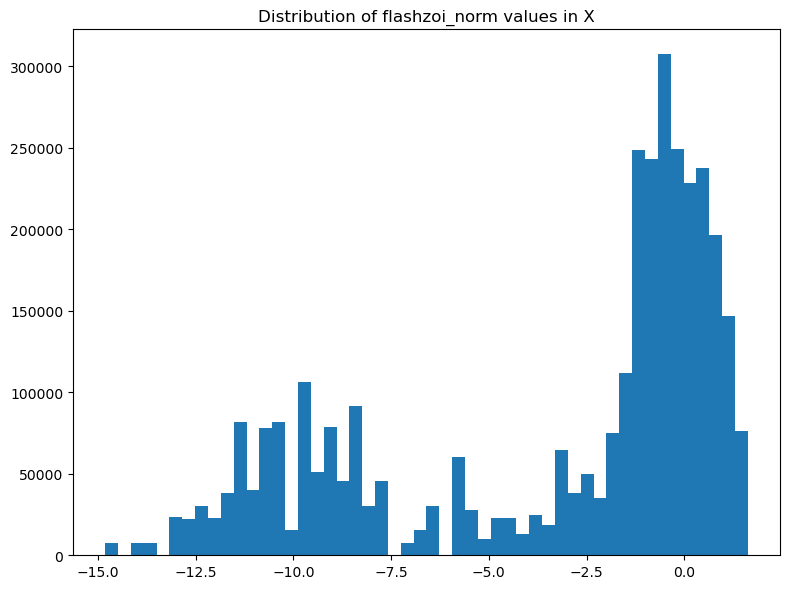

In [628]:
import matplotlib.pyplot as plt

print(X.min(axis=None), X.max(axis=None), X.mean(axis=None))

plt.figure(figsize=(8, 6))
plt.hist(X.values.flatten(), bins=50)

plt.title('Distribution of flashzoi_norm values in X')
plt.tight_layout()
plt.show()


In [ ]:
# from sklearn.manifold import TSNE

# dr_out = TSNE(n_components=2, 
#               random_state=42, 
#               verbose=1,  
#               perplexity=50
#              ).fit_transform(X)
# dr_out.shape

import src.autoencoder as ae

method  = "autoencoder"
if method == "umap":
    import umap
    dr_out = umap.UMAP(
        n_components=2,
        random_state=42,
        verbose=True
    ).fit_transform(X)
    dr_out.shape

elif method == "autoencoder":
    ae_out = ae.train_autoencoder(X,
                               n_epochs=100,
                               batch_size=128,
                               lr=1e-3,
                               weight_decay=1e-5,
                               use_contrastive=True,
                               contrastive_weight=1.0,
                               temperature=0.5,
                               noise_std=0.1, 
                               seed=42,
                               normalize=True
                               )
    dr_out = ae_out["embeddings"] 

Epoch 1/100, Loss: 9.6392
Epoch 10/100, Loss: 8.9468
Epoch 20/100, Loss: 7.7666
Epoch 30/100, Loss: 7.5225
Epoch 40/100, Loss: 7.5084
Epoch 50/100, Loss: 7.5087
Epoch 60/100, Loss: 7.5056
Epoch 70/100, Loss: 7.5064
Epoch 80/100, Loss: 7.5047
Epoch 90/100, Loss: 7.5056
Epoch 100/100, Loss: 7.5048
Reconstruction error: 0.0609


Prepare embeddings df with participant metadata.

In [647]:
dr_df = pd.concat(
    [pd.DataFrame({'sample': X.index.get_level_values(0)}),
     pd.DataFrame(dr_out, columns=[f"dim{i+1}" for i in range(dr_out.shape[1])])],
     axis=1
     ).merge(haps_to_samples[['cohort','sample','sex','population','population_name','superpopulation']].drop_duplicates(subset=["sample"]), 
             on="sample", how="left")
if 'cohort' not in dr_df.columns:
    dr_df['cohort'] = dr_df['cohort_sample'].str.split(":").str[0]
    dr_df.loc[dr_df['cohort'].str.startswith("HGDP"), "cohort"] = "HGDP"
# Reassign nonstandard population codes
dr_df.loc[dr_df['superpopulation']=="EUR,AFR", "superpopulation"] = "AFR"
dr_df.shape

(3825, 8)

Interactive plot.

In [ ]:
# Example: interactive plot placeholder
import plotly.express as px
fig = px.scatter(
    dr_df, x='dim1', y='dim2', color='superpopulation',
    hover_data=['sample', 'population', 'population_name', 'cohort', 'sex']
)
fig.show()